# Analise de Funil de Vendas e Teste A/A/B - App de Alimentos

## Contexto

Esta e uma startup que vende produtos alimenticios. O time de produto criou um app
para os clientes fazerem pedidos, e o time de design alterou as fontes usadas em
todo o aplicativo. A gerencia quer saber se essa mudanca de fonte afeta o
comportamento dos usuarios antes de decidir se a mudanca vale a pena ser mantida.

Para responder essa pergunta, os usuarios foram divididos em 3 grupos
experimentais ao acessar o app:

- **Grupo 246** - controle (fontes antigas)
- **Grupo 247** - controle (fontes antigas)
- **Grupo 248** - teste (fontes novas)

Os grupos 246 e 247 sao dois grupos de controle iguais entre si (ambos com a fonte
antiga). Eles existem para fazer um **teste A/A**: se nao houver diferenca entre
246 e 247, isso confirma que a divisao aleatoria dos usuarios em grupos esta
funcionando corretamente, dando confianca ao resultado do teste A/B (246/247 vs 248).

## Objetivo

1. Estudar o **funil de vendas**: entender como os usuarios avancam (ou desistem)
   nas etapas desde abrir o app até finalizar a compra.
2. Avaliar o **teste A/A/B**: verificar se a mudanca de fonte (grupo 248) teve
   impacto estatisticamente significativo no comportamento dos usuarios, comparado
   aos grupos de controle (246 e 247).

## Perguntas de negocio

- Como os usuarios progridem pelo funil de vendas até a compra?
- Em qual etapa do funil ocorre a maior perda de usuarios?
- Qual proporcao de usuarios completa o funil inteiro?
- Os grupos de controle (246 e 247) sao equivalentes, validando o experimento?
- A mudanca de fonte no app causa impacto estatisticamente significativo na conversao?


## Passo 1 - Carregar os dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Carregamento do dataset
df = pd.read_csv('logs_exp_us.csv', sep='\t')

df.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


## Passo 2 - Preparar os dados

In [2]:
# Renomeia colunas para snake_case
df.columns = ['event_name', 'device_id_hash', 'event_timestamp', 'exp_id']

# Verifica tipos de dados e valores ausentes
df.info()
print ()
# Verifica e remove linhas duplicadas
n_duplicados = df.duplicated().sum()
print(f'Linhas duplicadas: {n_duplicados}')

df = df.drop_duplicates().reset_index(drop=True)
print(f'Linhas apos remover duplicatas: {len(df)}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   event_name       244126 non-null  object
 1   device_id_hash   244126 non-null  int64 
 2   event_timestamp  244126 non-null  int64 
 3   exp_id           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB

Linhas duplicadas: 413
Linhas apos remover duplicatas: 243713


In [3]:
# Cria coluna de data/hora formatada a partir do timestamp Unix
df['event_datetime'] = pd.to_datetime(df['event_timestamp'], unit='s')

# Cria coluna separada apenas com a data (sem hora)
df['event_date'] = df['event_datetime'].dt.date

df.head()

,event_name,device_id_hash,event_timestamp,exp_id,event_datetime,event_date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


## Passo 3 - Explorar os dados

In [4]:
# Total de eventos e usuarios unicos
total_eventos = len(df)
total_usuarios = df['device_id_hash'].nunique()
media_eventos_por_usuario = total_eventos / total_usuarios

print(f'Total de eventos: {total_eventos}')
print(f'Usuarios unicos: {total_usuarios}')
print(f'Media de eventos por usuario: {media_eventos_por_usuario:.2f}')
print()

# Datas minima e maxima
data_min = df['event_datetime'].min()
data_max = df['event_datetime'].max()
print(f'Data minima: {data_min}')
print(f'Data maxima: {data_max}')

Total de eventos: 243713
Usuarios unicos: 7551
Media de eventos por usuario: 32.28

Data minima: 2019-07-25 04:43:36
Data maxima: 2019-08-07 21:15:17


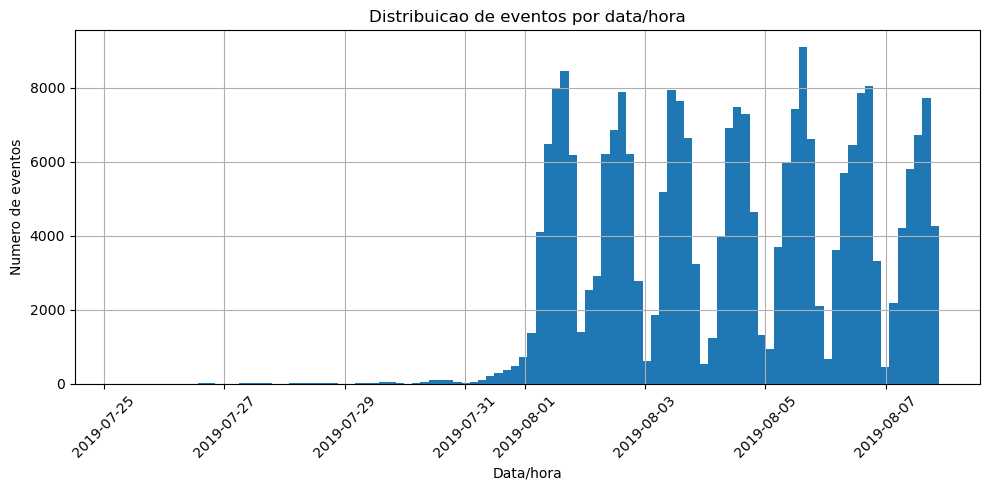

event_date
2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      412
2019-07-31     2030
2019-08-01    36141
2019-08-02    35554
2019-08-03    33282
2019-08-04    32968
2019-08-05    36058
2019-08-06    35788
2019-08-07    31096
dtype: int64


In [5]:
# Histograma de eventos por data/hora para identificar o ponto de corte
plt.figure(figsize=(10, 5))
df['event_datetime'].hist(bins=100)
plt.title('Distribuicao de eventos por data/hora')
plt.xlabel('Data/hora')
plt.ylabel('Numero de eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Contagem de eventos por dia para identificar o corte com precisao
eventos_por_dia = df.groupby('event_date').size()
print(eventos_por_dia)

In [6]:
# O volume de eventos salta de forma abrupta em 2019-08-01 (de ~2000 para ~36000/dia)
# Isso indica que os dados anteriores a essa data sao incompletos (provavelmente logging
# ainda nao estava totalmente ativo) e devem ser descartados da analise.
cutoff = pd.Timestamp('2019-08-01').date()

df_antes_corte = df[df['event_date'] < cutoff]
df_depois_corte = df[df['event_date'] >= cutoff].reset_index(drop=True)

# Quantos eventos e usuarios foram perdidos com o corte
eventos_perdidos = len(df_antes_corte)
pct_eventos_perdidos = eventos_perdidos / len(df)

usuarios_antes = set(df_antes_corte['device_id_hash'])
usuarios_depois = set(df_depois_corte['device_id_hash'])
usuarios_perdidos_de_fato = usuarios_antes - usuarios_depois

print(f'Eventos perdidos com o corte: {eventos_perdidos} ({pct_eventos_perdidos:.2%})')
print(f'Usuarios que so aparecem antes do corte (perdidos de fato): {len(usuarios_perdidos_de_fato)}')

# Usa o dataframe filtrado a partir daqui
df = df_depois_corte
print(f'Total de eventos apos o corte: {len(df)}')
print(f'Total de usuarios apos o corte: {df["device_id_hash"].nunique()}')

Eventos perdidos com o corte: 2826 (1.16%)
Usuarios que so aparecem antes do corte (perdidos de fato): 17
Total de eventos apos o corte: 240887
Total de usuarios apos o corte: 7534


In [7]:
# Confirma a presenca de usuarios dos 3 grupos experimentais
print('Usuarios unicos por grupo experimental:')
print(df.groupby('exp_id')['device_id_hash'].nunique())

Usuarios unicos por grupo experimental:
exp_id
246    2484
247    2513
248    2537
Name: device_id_hash, dtype: int64


## Passo 4 - Analisar o funil de eventos

In [8]:
# Lista de eventos e sua frequencia (total de ocorrencias)
frequencia_eventos = df['event_name'].value_counts()
print('Frequencia de eventos:')
print(frequencia_eventos)
print()

# Numero de usuarios unicos que realizaram cada evento
usuarios_por_evento = df.groupby('event_name')['device_id_hash'].nunique().sort_values(ascending=False)
print('Usuarios unicos por evento:')
print(usuarios_por_evento)

Frequencia de eventos:
event_name
MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: count, dtype: int64

Usuarios unicos por evento:
event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: device_id_hash, dtype: int64


In [9]:
# Define a ordem logica do funil principal (o evento "Tutorial" nao faz parte
# da jornada de compra, por isso e excluido do funil)
funil_ordem = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

usuarios_por_etapa = [df[df['event_name'] == evento]['device_id_hash'].nunique() for evento in funil_ordem]

funil_df = pd.DataFrame({
    'evento': funil_ordem,
    'usuarios_unicos': usuarios_por_etapa
})
funil_df

,evento,usuarios_unicos
0,MainScreenAppear,7419
1,OffersScreenAppear,4593
2,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539


In [10]:
# Calcula a taxa de conversao entre cada etapa consecutiva do funil
funil_df['taxa_conversao'] = funil_df['usuarios_unicos'] / funil_df['usuarios_unicos'].shift(1)
funil_df['taxa_conversao'] = funil_df['taxa_conversao'].fillna(1.0)

# Taxa de conversao em relacao ao primeiro passo do funil
funil_df['taxa_conversao_total'] = funil_df['usuarios_unicos'] / funil_df['usuarios_unicos'].iloc[0]

print(funil_df)
print()

# Identifica a etapa com maior perda de usuarios (menor taxa de conversao entre etapas)
etapa_maior_perda = funil_df.iloc[1:].sort_values('taxa_conversao').iloc[0]
print(f"Etapa com maior perda: chegando em '{etapa_maior_perda['evento']}', "
      f"com conversao de apenas {etapa_maior_perda['taxa_conversao']:.2%} em relacao a etapa anterior")

                    evento  usuarios_unicos  taxa_conversao  \
0         MainScreenAppear             7419        1.000000   
1       OffersScreenAppear             4593        0.619086   
2         CartScreenAppear             3734        0.812976   
3  PaymentScreenSuccessful             3539        0.947777   

   taxa_conversao_total  
0              1.000000  
1              0.619086  
2              0.503302  
3              0.477018  

Etapa com maior perda: chegando em 'OffersScreenAppear', com conversao de apenas 61.91% em relacao a etapa anterior


In [11]:
# Proporcao de usuarios que completam o funil inteiro (do primeiro ao ultimo passo)
proporcao_funil_completo = funil_df['usuarios_unicos'].iloc[-1] / funil_df['usuarios_unicos'].iloc[0]
print(f'Proporcao de usuarios que completam o funil inteiro (MainScreen -> Pagamento): {proporcao_funil_completo:.2%}')

Proporcao de usuarios que completam o funil inteiro (MainScreen -> Pagamento): 47.70%


## Passo 5 - Analisar o teste A/A/B

In [12]:
# Contagem de usuarios unicos por grupo experimental
usuarios_por_grupo = df.groupby('exp_id')['device_id_hash'].nunique()
print('Usuarios unicos por grupo experimental:')
print(usuarios_por_grupo)

Usuarios unicos por grupo experimental:
exp_id
246    2484
247    2513
248    2537
Name: device_id_hash, dtype: int64


In [13]:
def proporcao_e_sucessos(data, filtro_grupo, evento):
    """Retorna (n_usuarios_no_grupo, n_usuarios_do_grupo_que_fizeram_o_evento)."""
    grupo = data[filtro_grupo]
    n = grupo['device_id_hash'].nunique()
    sucesso = grupo[grupo['event_name'] == evento]['device_id_hash'].nunique()
    return n, sucesso


def z_test_proporcoes(n_a, sucesso_a, n_b, sucesso_b):
    """Z-test para diferenca entre duas proporcoes. Retorna (p_a, p_b, p_value)."""
    p_a, p_b = sucesso_a / n_a, sucesso_b / n_b
    p_combinada = (sucesso_a + sucesso_b) / (n_a + n_b)
    erro_padrao = np.sqrt(p_combinada * (1 - p_combinada) * (1 / n_a + 1 / n_b))
    z = (p_a - p_b) / erro_padrao
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return p_a, p_b, p_value


def comparar_grupos(data, filtro_a, filtro_b, eventos, nome_a, nome_b, alpha=0.05):
    """Compara dois grupos para uma lista de eventos e imprime os resultados."""
    print(f'--- {nome_a} vs {nome_b} ---')
    resultados = []
    for evento in eventos:
        n_a, sucesso_a = proporcao_e_sucessos(data, filtro_a, evento)
        n_b, sucesso_b = proporcao_e_sucessos(data, filtro_b, evento)
        p_a, p_b, p_value = z_test_proporcoes(n_a, sucesso_a, n_b, sucesso_b)
        significativo = p_value < alpha
        print(f'{evento}: p_{nome_a}={p_a:.4f}  p_{nome_b}={p_b:.4f}  '
              f'p-value={p_value:.4f}  significativo={significativo}')
        resultados.append({'evento': evento, 'p_value': p_value, 'significativo': significativo})
    return pd.DataFrame(resultados)


eventos_funil = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

In [14]:
# Teste A/A: compara os dois grupos de controle (246 vs 247) para validar o experimento.
# Se houver diferenca significativa aqui, algo esta errado na divisao dos grupos
# e os resultados do teste A/B (248) nao seriam confiaveis.
resultado_aa = comparar_grupos(
    df,
    df['exp_id'] == 246,
    df['exp_id'] == 247,
    eventos_funil,
    nome_a='246',
    nome_b='247'
)

--- 246 vs 247 ---


MainScreenAppear: p_246=0.9863  p_247=0.9853  p-value=0.7571  significativo=False
OffersScreenAppear: p_246=0.6208  p_247=0.6049  p-value=0.2481  significativo=False
CartScreenAppear: p_246=0.5097  p_247=0.4926  p-value=0.2288  significativo=False
PaymentScreenSuccessful: p_246=0.4831  p_247=0.4608  p-value=0.1146  significativo=False


In [15]:
# Cria uma coluna combinando os dois grupos de controle em um so grupo
df['grupo'] = df['exp_id'].map({246: 'controle', 247: 'controle', 248: 'teste'})

# Compara o grupo de teste (248) com cada grupo de controle separadamente
resultado_246_248 = comparar_grupos(
    df, df['exp_id'] == 246, df['exp_id'] == 248, eventos_funil, nome_a='246', nome_b='248'
)
print()
resultado_247_248 = comparar_grupos(
    df, df['exp_id'] == 247, df['exp_id'] == 248, eventos_funil, nome_a='247', nome_b='248'
)
print()

# Compara o grupo de teste (248) com os dois grupos de controle combinados
resultado_combinado_248 = comparar_grupos(
    df, df['grupo'] == 'controle', df['grupo'] == 'teste', eventos_funil,
    nome_a='controle_combinado', nome_b='248'
)

--- 246 vs 248 ---
MainScreenAppear: p_246=0.9863  p_248=0.9827  p-value=0.2950  significativo=False
OffersScreenAppear: p_246=0.6208  p_248=0.6035  p-value=0.2084  significativo=False
CartScreenAppear: p_246=0.5097  p_248=0.4848  p-value=0.0784  significativo=False
PaymentScreenSuccessful: p_246=0.4831  p_248=0.4655  p-value=0.2123  significativo=False

--- 247 vs 248 ---
MainScreenAppear: p_247=0.9853  p_248=0.9827  p-value=0.4587  significativo=False
OffersScreenAppear: p_247=0.6049  p_248=0.6035  p-value=0.9198  significativo=False
CartScreenAppear: p_247=0.4926  p_248=0.4848  p-value=0.5786  significativo=False
PaymentScreenSuccessful: p_247=0.4608  p_248=0.4655  p-value=0.7373  significativo=False

--- controle_combinado vs 248 ---
MainScreenAppear: p_controle_combinado=0.9858  p_248=0.9827  p-value=0.2942  significativo=False
OffersScreenAppear: p_controle_combinado=0.6128  p_248=0.6035  p-value=0.4343  significativo=False
CartScreenAppear: p_controle_combinado=0.5011  p_248=0.4

In [16]:
# Discussao sobre multiplas comparacoes
# Foram feitas 4 comparacoes de grupos (A/A, 246 vs 248, 247 vs 248, combinado vs 248)
# x 4 eventos = 16 testes de hipotese. Com alpha=0.05, a chance de pelo menos um
# falso positivo por acaso sobe bastante. Aplicamos a correcao de Bonferroni para
# manter o erro global controlado.
n_comparacoes_de_grupo = 4
n_eventos = len(eventos_funil)
n_testes_total = n_comparacoes_de_grupo * n_eventos

alpha = 0.05
alpha_bonferroni = alpha / n_testes_total

print(f'Numero total de testes realizados: {n_testes_total}')
print(f'Alpha original: {alpha}')
print(f'Alpha ajustado (Bonferroni): {alpha_bonferroni:.5f}')
print()

todos_resultados = pd.concat([
    resultado_aa.assign(comparacao='246 vs 247 (A/A)'),
    resultado_246_248.assign(comparacao='246 vs 248'),
    resultado_247_248.assign(comparacao='247 vs 248'),
    resultado_combinado_248.assign(comparacao='controle combinado vs 248'),
])
todos_resultados['significativo_bonferroni'] = todos_resultados['p_value'] < alpha_bonferroni

print(todos_resultados[['comparacao', 'evento', 'p_value', 'significativo', 'significativo_bonferroni']]
      .to_string(index=False))

Numero total de testes realizados: 16
Alpha original: 0.05
Alpha ajustado (Bonferroni): 0.00313

               comparacao                  evento  p_value  significativo  significativo_bonferroni
         246 vs 247 (A/A)        MainScreenAppear 0.757060          False                     False
         246 vs 247 (A/A)      OffersScreenAppear 0.248095          False                     False
         246 vs 247 (A/A)        CartScreenAppear 0.228834          False                     False
         246 vs 247 (A/A) PaymentScreenSuccessful 0.114567          False                     False
               246 vs 248        MainScreenAppear 0.294972          False                     False
               246 vs 248      OffersScreenAppear 0.208362          False                     False
               246 vs 248        CartScreenAppear 0.078429          False                     False
               246 vs 248 PaymentScreenSuccessful 0.212255          False                     False
   

## Conclusao

- **Teste A/A (246 vs 247):** nenhuma diferenca estatisticamente significativa foi encontrada em nenhum evento do funil, o que valida o processo de divisao aleatoria dos grupos e da confiabilidade ao desenho do experimento.
- **Teste A/B (248 vs cada controle e vs controle combinado):** nenhuma das comparacoes (246 vs 248, 247 vs 248, controle combinado vs 248) mostrou diferenca estatisticamente significativa em qualquer etapa do funil, mesmo usando o alpha original de 0.05 — e a conclusao se mantem inalterada apos a correcao de Bonferroni para multiplas comparacoes.
- **Conclusao geral:** os dados nao fornecem evidencia estatistica de que a mudanca de fonte no aplicativo tenha causado impacto no comportamento dos usuarios ao longo do funil de vendas. Recomenda-se nao adotar a mudanca de fonte com base apenas neste resultado, ou conduzir um teste com maior poder estatistico (mais usuarios/tempo) caso o efeito esperado seja pequeno.